# MediaPipe Skeleton Extraction
# Ruder-Videos → Skelett auf schwarzem Hintergrund → gespeicherte Frames für CNN

## Schritt 0: Installation (nur einmal ausführen)

In [89]:
!pip install mediapipe opencv-python


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [90]:
import cv2
import numpy as np
import urllib.request
import ssl
from pathlib import Path
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# SSL-Fix für macOS
ssl_context = ssl._create_unverified_context()

POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),
    (23,25),(25,27),(27,29),(27,31),(29,31),
    (24,26),(26,28),(28,30),(28,32),(30,32),
]

MODEL_PATH = "pose_landmarker.task"
if not Path(MODEL_PATH).exists():
    print("Lade Modell herunter (~7 MB)...")
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task"
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(MODEL_PATH, "wb") as f:
            f.write(response.read())
    print("Modell gespeichert.")
else:
    print("Modell bereits vorhanden.")

print("Libraries loaded.")

Modell bereits vorhanden.
Libraries loaded.


## Schritt 1: Pfade 

In [91]:
from pathlib import Path

# ── INPUT ──────────────────────────────────────────────────────────────
VIDEO_PATH = Path("/Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/OG_Videos/mar-GOOD-fast.mov")

# ── OUTPUT ─────────────────────────────────────────────────────────────
# Data directory (derived from the video path)
DATA_DIR = VIDEO_PATH.parent.parent  # .../1_DatasetCharacteristics/Data
FRAMES_BASE = DATA_DIR / "skeleton_frames"
OUTPUT_DIR = FRAMES_BASE / (VIDEO_PATH.stem + "-skeleton")
VIDEO_DIR = DATA_DIR / "skeleton_videos"

# ── EDA output (zusätzlich) ─────────────────────────────────────────────
# Aggregierte EDA-Ergebnisse (Stroke times + Plots) unter: '.../1_DatasetCharacteristics/EDA_data/<video_stem>-skeleton'
EDA_BASE = DATA_DIR.parent / "EDA_data"
EDA_OUTPUT_DIR = EDA_BASE / (VIDEO_PATH.stem + "-skeleton")

# create directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FRAME_SIZE  = (256, 256)   # Auflösung der gespeicherten Skelett-Frames
SAVE_VIDEO  = True          # True → zusätzlich ein zusammengesetztes .mp4 speichern

print(f"Video:  {VIDEO_PATH}")
print(f"Frames output: {OUTPUT_DIR}")
print(f"Video output: {VIDEO_DIR}")
print(f"EDA output: {EDA_OUTPUT_DIR}")

Video:  /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/OG_Videos/mar-GOOD-fast.mov
Frames output: /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_frames/mar-GOOD-fast-skeleton
Video output: /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_videos
EDA output: /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/EDA_data/mar-GOOD-fast-skeleton


## Schritt 2: Skelett-Extraktion ausführen

In [ ]:
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"FPS: {fps:.1f}  |  Frames gesamt: {total_frames}")

video_writer = None
out_video_path = None
if SAVE_VIDEO:
    # Save the assembled video in the dedicated VIDEO_DIR
    out_video_path = str(VIDEO_DIR / (VIDEO_PATH.stem + "_skeleton.mp4"))
    video_writer = cv2.VideoWriter(
        out_video_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, FRAME_SIZE
    )

def draw_skeleton(canvas, landmarks, frame_shape):
    h, w = frame_shape[:2]
    points = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks]
    for a, b in POSE_CONNECTIONS:
        cv2.line(canvas, points[a], points[b], (180, 180, 180), 2)
    for pt in points:
        cv2.circle(canvas, pt, 3, (255, 255, 255), -1)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
)

saved = 0
no_pose = 0

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        timestamp_ms = int(saved * 1000 / fps)
        results = landmarker.detect_for_video(mp_image, timestamp_ms)

        canvas = np.zeros((frame.shape[0], frame.shape[1], 3), dtype=np.uint8)

        label = "GOOD"       # je nach Video anpassen
        all_rows = []

        if results.pose_landmarks:
            draw_skeleton(canvas, results.pose_landmarks[0], frame.shape)
            # Koordinaten extrahieren und speichern
            row = []
            for point in results.pose_landmarks[0]:
                row.extend([point.x, point.y, point.z])
            row.append(label)   # z.B. "GOOD" oder "BAD"
            all_rows.append(row)
        else:
            no_pose += 1

        canvas = cv2.resize(canvas, FRAME_SIZE)
        cv2.imwrite(str(OUTPUT_DIR / f"frame_{saved:05d}.png"), canvas)

        if video_writer:
            video_writer.write(canvas)

        saved += 1

cap.release()
if video_writer:
    video_writer.release()

print(f"\nFertig! {saved} Frames gespeichert → {OUTPUT_DIR}")
print(f"Frames ohne erkannte Pose: {no_pose}")
if SAVE_VIDEO:
    print(f"Video gespeichert → {out_video_path}")

FPS: 30.0  |  Frames gesamt: 4217


I0000 00:00:1778612623.286739 13559007 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1778612623.347454 13559010 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778612623.365250 13559011 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



Fertig! 4217 Frames gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_frames/mar-GOOD-fast-skeleton
Frames ohne erkannte Pose: 0
Video gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_videos/mar-GOOD-fast_skeleton.mp4


In [ ]:
#Landmark-Daten in CSV speichern
cols = [f"lm{i}_{ax}" for i in range(33) for ax in ["x", "y", "z"]] + ["label"]
df = pd.DataFrame(all_rows, columns=cols)
df.to_csv("landmarks_cla-GUT-fast.csv", index=False)

# Alle CSVs zusammenführen (falls mehrere Videos verarbeitet wurden)
df_all = pd.concat([pd.read_csv(f) for f in Path(".").glob("landmarks_*.csv")])
df_all.to_csv("landmarks_all.csv", index=False)

## Schritt 3: Vorschau — ersten Frame anzeigen

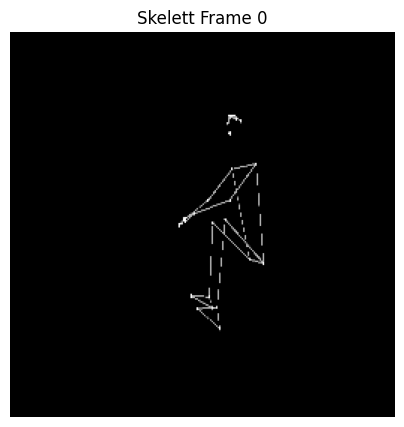

In [93]:
import matplotlib.pyplot as plt

preview = cv2.imread(str(OUTPUT_DIR / "frame_00000.png"))
preview = cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(preview)
plt.title("Skelett Frame 0")
plt.axis("off")
plt.show()

## Schritt 4: Zyklusdetektion — Schläge zählen

In [94]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [95]:
# Hüft-Trajektorie aus dem Originalvideo extrahieren (nur Koordinaten, keine Bilder)
cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
)

hip_x = []

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        results = landmarker.detect_for_video(mp_image, int(frame_idx * 1000 / fps))

        if results.pose_landmarks:
            lm = results.pose_landmarks[0]
            # Durchschnitt linke (23) + rechte (24) Hüfte
            hip_x.append((lm[23].x + lm[24].x) / 2)
        else:
            hip_x.append(hip_x[-1] if hip_x else 0.5)

        frame_idx += 1

cap.release()
hip_x = np.array(hip_x)
print(f"Trajektorie extrahiert: {len(hip_x)} Frames bei {fps:.0f} FPS")

I0000 00:00:1778612668.413091 13559662 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1778612668.456243 13559671 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778612668.463064 13559668 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Trajektorie extrahiert: 4217 Frames bei 30 FPS


In [96]:
from scipy.signal import find_peaks, savgol_filter

# Signal glätten (Fenstergröße = ~0.5 Sekunden)
window = max(int(fps * 0.5) | 1, 5)  # ungerade Zahl
smoothed = savgol_filter(hip_x, window_length=window, polyorder=3)

# Mindestabstand zwischen Peaks = 0.8 Sekunden (entspricht max ~75 Schläge/Min)
min_dist = int(fps * 0.8)

peaks,   _ = find_peaks( smoothed, distance=min_dist, prominence=0.01)
valleys, _ = find_peaks(-smoothed, distance=min_dist, prominence=0.01)

# Schlaganzahl = Anzahl Peaks (Finish-Position) oder Täler (Catch-Position)
n_strokes   = len(peaks)
duration_s  = len(hip_x) / fps
rate        = n_strokes / duration_s * 60

print(f"Erkannte Schläge:  {n_strokes}")
print(f"Videodauer:        {duration_s:.1f} s")
print(f"Schlagrate:        {rate:.1f} Schläge/Minute")

# ── Plot ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

time = np.arange(len(hip_x)) / fps

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, hip_x,   color="gray",  alpha=0.4, linewidth=1, label="Rohsignal")
ax.plot(time, smoothed, color="steelblue", linewidth=2, label="Geglättet")
ax.plot(time[peaks],   smoothed[peaks],   "v", color="tomato",    markersize=8, label=f"Finish ({n_strokes}×)")
ax.plot(time[valleys], smoothed[valleys], "^", color="limegreen",  markersize=8, label=f"Catch ({len(valleys)}×)")
ax.set_xlabel("Zeit (s)")
ax.set_ylabel("Hüft-x (normiert)")
ax.set_title(f"{VIDEO_PATH.stem}  —  {n_strokes} Schläge  |  {rate:.1f} SPM")
ax.legend()
plt.tight_layout()
plt.show()

# Speichern der Schlagzeiten in einer Textdatei im EDA_OUTPUT_DIR (jeweils Finish- und Catch-Zeiten) & speichern des Plots als .png
output_txt = EDA_OUTPUT_DIR / "stroke_times.txt"
with open(output_txt, "w") as f:
    f.write("Finish-Zeiten (s):\n")
    f.write(", ".join(f"{time[p]:.2f}" for p in peaks) + "\n\n")
    f.write("Catch-Zeiten (s):\n")
    f.write(", ".join(f"{time[v]:.2f}" for v in valleys) + "\n")
print(f"Stroke times saved → {output_txt}")

# Speichern des Plots als .png im EDA_OUTPUT_DIR
output_png = EDA_OUTPUT_DIR / "stroke_plot.png"
fig.savefig(output_png)
print(f"Plot saved → {output_png}")

Erkannte Schläge:  62
Videodauer:        140.6 s
Schlagrate:        26.5 Schläge/Minute


Stroke times saved → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/EDA_data/mar-GOOD-fast-skeleton/stroke_times.txt
Plot saved → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/EDA_data/mar-GOOD-fast-skeleton/stroke_plot.png
